# Laboratorio 8
Alina Carías, Daniel Machic, Ariela Mishaan  
Github: https://github.com/ArielaMishaanCohen/LAB8.git

## Entorno

In [ ]:
# Verificar si hay GPU disponible
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️  No hay GPU. El entrenamiento será lento en CPU.")

PyTorch version: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4
Memoria GPU: 15.64 GB


In [ ]:
!pip install -q ultralytics          # YOLOv8
!pip install -q fiftyone              # Descarga de Open Images V7
!pip install -q pycocotools           # Métricas COCO
!pip install -q torchvision           # Faster R-CNN
!pip install -q albumentations        # Augmentaciones
!pip install -q matplotlib seaborn pandas numpy pillow tqdm

print("✅ Dependencias instaladas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 129.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 12.5 MB/s eta 0:

In [ ]:
import os
import json
import time
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import defaultdict

import torch
import torchvision
from torchvision import transforms

import fiftyone as fo
import fiftyone.zoo as foz

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


In [ ]:

# Semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dispositivo
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {DEVICE}")

# Directorios base
BASE_DIR = Path('/content/visorshelf')
DATA_DIR = BASE_DIR / 'data'
MODELS_DIR = BASE_DIR / 'models'
RESULTS_DIR = BASE_DIR / 'results'

for d in [BASE_DIR, DATA_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Directorios creados")

Dispositivo: cuda
Directorios creados


## 1. Preparación del dataset

### Dataset

Se usará **Open Images V7** filtrado por categorías de productos de anaquel.

**Fuente:** Open Images V7 via FiftyOne

**Categorías seleccionadas:** bottle, tin can, food, cosmetics

**Proceso:** descarga automática con anotaciones en formato COCO JSON, conversión a formato YOLO .txt para el modelo YOLOv8.

In [ ]:

# Categorías representativas de productos en anaquel
SHELF_CLASSES = ["Bottle", "Tin can", "Food", "Cosmetics"]

print("Descargando dataset Open Images V7...")
print(f"Clases: {SHELF_CLASSES}")
print(f"Train: 500 imágenes | Val: 100 imágenes | Test: 100 imágenes")

# Descargar split de entrenamiento
dataset_train = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=SHELF_CLASSES,
    max_samples=500,
    seed=SEED,
    shuffle=True,
    dataset_name="sku_train"
)

# Descargar split de validación
dataset_val = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["detections"],
    classes=SHELF_CLASSES,
    max_samples=100,
    seed=SEED,
    shuffle=True,
    dataset_name="sku_val"
)

# Descargar split de prueba
dataset_test = foz.load_zoo_dataset(
    "open-images-v7",
    split="test",
    label_types=["detections"],
    classes=SHELF_CLASSES,
    max_samples=100,
    seed=SEED,
    shuffle=True,
    dataset_name="sku_test"
)

print(f"\nDataset descargado:")
print(f"   Train: {len(dataset_train)} imágenes")
print(f"   Val:   {len(dataset_val)} imágenes")
print(f"   Test:  {len(dataset_test)} imágenes")

Descargando dataset Open Images V7...
Clases: ['Bottle', 'Tin can', 'Food', 'Cosmetics']
Train: 500 imágenes | Val: 100 imágenes | Test: 100 imágenes


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [2.5s elapsed, 0s remaining, 1.8Gb/s]        


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [2.5s elapsed, 0s remaining, 1.8Gb/s]        


...

 100% |█████████████████| 100/100 [948.1ms elapsed, 0s remaining, 105.5 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [948.1ms elapsed, 0s remaining, 105.5 samples/s]      


Dataset 'sku_test' created


INFO:fiftyone.zoo.datasets:Dataset 'sku_test' created



Dataset descargado:
   Train: 500 imágenes
   Val:   100 imágenes
   Test:  100 imágenes


### Preprocesamiento

Se exporta el dataset en dos formatos:

- COCO JSON -> para Faster R-CNN (torchvision)

- YOLO.txt -> para YOLOv8 (Ultralytics)

Faster R-CNN de torchvision espera anotaciones en formato COCO con coordenadas absolutas ```[x_min, y_min, width, height]```, mientras que YOLOv8 usa coordenadas normalizadas ```[cx, cy, w, h]``` relativas al tamaño de la imagen.

In [ ]:
COCO_DIR = DATA_DIR / 'coco'
COCO_DIR.mkdir(parents=True, exist_ok=True)

for split_name, dataset in [("train", dataset_train), ("val", dataset_val), ("test", dataset_test)]:
    export_path = str(COCO_DIR / split_name)

    dataset.export(
        export_dir=export_path,
        dataset_type=fo.types.COCODetectionDataset,
        label_field="ground_truth",  # 👈 FIX
        classes=SHELF_CLASSES,
    )

    print(f"✅ Exportado COCO JSON: {split_name} → {export_path}")

print("\n📂 Estructura COCO generada:")
!find {COCO_DIR} -name '*.json' | head -5

   0% |/----------------|   2/500 [113.6ms elapsed, 28.3s remaining, 17.6 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Man' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Clothing' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Beer' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Human face' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Helmet' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Person' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/d

   4% |-----------------|  20/500 [214.6ms elapsed, 5.1s remaining, 93.2 samples/s]  

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Wok' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Girl' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Tree' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Coffee cup' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Coffee' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Chopsticks' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/d

   8% |█\---------------|  40/500 [318.5ms elapsed, 3.7s remaining, 125.6 samples/s] 

...

  51% |████████---------|  51/100 [224.9ms elapsed, 216.1ms remaining, 226.7 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Tomato' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Bell pepper' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Sandwich' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Hot dog' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Carrot' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Lipstick' not in provided classes
  warnings.warn(msg)


 100% |█████████████████| 100/100 [391.3ms elapsed, 0s remaining, 255.6 samples/s]      


/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Cheese' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Egg (Food)' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Guacamole' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Hamburger' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/coco.py:890: UserWarning: Ignoring object with label 'Bread' not in provided classes
  warnings.warn(msg)
INFO:eta.core.utils: 100% |█████████████████| 100/100 [391.3ms elapsed, 0s remaining, 255.6 samples/s]      


✅ Exportado COCO JSON: test → /content/visorshelf/data/coco/test

📂 Estructura COCO generada:
/content/visorshelf/data/coco/train/labels.json
/content/visorshelf/data/coco/val/labels.json
/content/visorshelf/data/coco/test/labels.json


In [ ]:
# Exportar en formato YOLO para YOLOv8
YOLO_DIR = DATA_DIR / 'yolo'
YOLO_DIR.mkdir(parents=True, exist_ok=True)

for split_name, dataset in [("train", dataset_train), ("val", dataset_val), ("test", dataset_test)]:
    export_path = str(YOLO_DIR / split_name)
    dataset.export(
        export_dir=export_path,
        dataset_type=fo.types.YOLOv5Dataset,
        label_field="ground_truth",
        classes=SHELF_CLASSES,
    )
    print(f"Exportado YOLO: {split_name} → {export_path}")

# Crear archivo dataset.yaml para YOLOv8
yaml_content = f"""path: {YOLO_DIR}
train: train/images
val: val/images
test: test/images

nc: {len(SHELF_CLASSES)}
names: {SHELF_CLASSES}
"""

yaml_path = YOLO_DIR / 'dataset.yaml'
yaml_path.write_text(yaml_content)
print(f"\ndataset.yaml creado: {yaml_path}")
print(yaml_content)

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Man' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Clothing' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Beer' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Human face' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Helmet' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Person' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python

  25% |████|------------| 126/500 [429.0ms elapsed, 1.3s remaining, 293.7 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Flowerpot' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Houseplant' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Human body' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Human hair' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Mammal' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Shorts' not in provided classes
  warnings.warn(msg)
/usr/lo

  40% |██████-----------| 200/500 [633.7ms elapsed, 950.6ms remaining, 315.6 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Lemon' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Juice' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Cocktail' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Lizard' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Goggles' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Sunglasses' not in provided classes
  warnings.warn(msg)
/usr/local/lib/py

...

  63% |██████████-------|  63/100 [243.0ms elapsed, 142.7ms remaining, 259.3 samples/s] 

/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Tomato' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Bell pepper' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Sandwich' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Hot dog' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Carrot' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Lipstick' not in provided classes
  warnings.warn(msg)


 100% |█████████████████| 100/100 [354.1ms elapsed, 0s remaining, 282.4 samples/s]      


/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Cheese' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Egg (Food)' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Guacamole' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Hamburger' not in provided classes
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/fiftyone/utils/yolo.py:1154: UserWarning: Ignoring object with label 'Bread' not in provided classes
  warnings.warn(msg)
INFO:eta.core.utils: 100% |█████████████████| 100/100 [354.1ms elapsed, 0s remaining, 282.4 samples/s]      


Exportado YOLO: test → /content/visorshelf/data/yolo/test

dataset.yaml creado: /content/visorshelf/data/yolo/dataset.yaml
path: /content/visorshelf/data/yolo
train: train/images
val: val/images
test: test/images

nc: 4
names: ['Bottle', 'Tin can', 'Food', 'Cosmetics']



### Análisis de la distribución de clases

Antes de entrenar, se analiza la distribución de clases para detectar desbalances que puedan afectar el entrenamiento.

In [ ]:
# Analizar distribución de clases en el dataset
def count_class_distribution(coco_json_path):
    """Cuenta instancias por clase desde un archivo COCO JSON."""
    with open(coco_json_path) as f:
        coco = json.load(f)

    # Mapa id → nombre
    cat_map = {c['id']: c['name'] for c in coco.get('categories', [])}

    counts = defaultdict(int)
    for ann in coco.get('annotations', []):
        cat_name = cat_map.get(ann['category_id'], 'Unknown')
        counts[cat_name] += 1

    return dict(counts)

In [ ]:

# Buscar archivos JSON COCO
train_json = list((COCO_DIR / 'train').rglob('*.json'))
val_json   = list((COCO_DIR / 'val').rglob('*.json'))
test_json  = list((COCO_DIR / 'test').rglob('*.json'))

splits_data = {}
for split_name, json_files in [('train', train_json), ('val', val_json), ('test', test_json)]:
    if json_files:
        splits_data[split_name] = count_class_distribution(json_files[0])
        print(f"\nDistribución [{split_name}]:")
        for cls, count in sorted(splits_data[split_name].items(), key=lambda x: -x[1]):
            print(f"   {cls:20s}: {count:5d} instancias")



Distribución [train]:
   Food                :   974 instancias
   Bottle              :   568 instancias
   Cosmetics           :    43 instancias
   Tin can             :    20 instancias

Distribución [val]:
   Food                :   154 instancias
   Bottle              :    15 instancias
   Tin can             :     2 instancias
   Cosmetics           :     1 instancias

Distribución [test]:
   Food                :   124 instancias
   Bottle              :    11 instancias
   Cosmetics           :     6 instancias
   Tin can             :     1 instancias


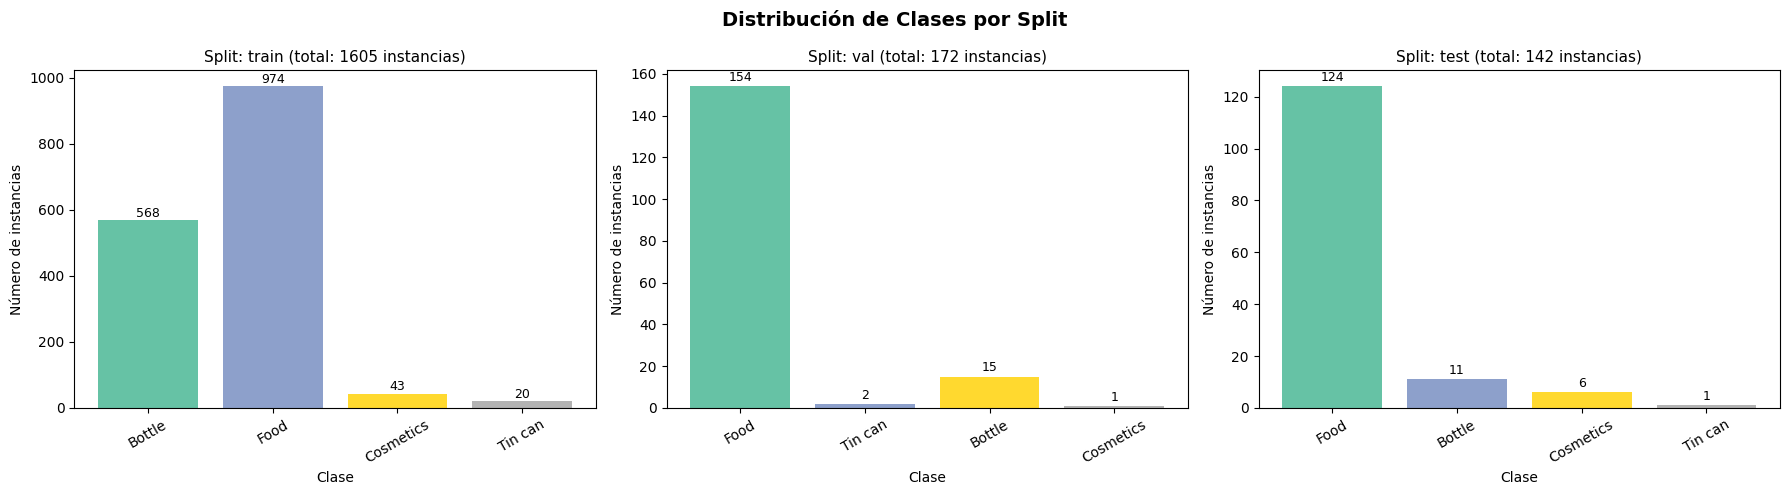

Gráfico guardado


In [ ]:

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Clases por Split', fontsize=14, fontweight='bold')

colors = plt.cm.Set2(np.linspace(0, 1, len(SHELF_CLASSES)))

for ax, (split_name, counts) in zip(axes, splits_data.items()):
    if counts:
        classes = list(counts.keys())
        values  = list(counts.values())
        bars = ax.bar(classes, values, color=colors[:len(classes)])
        ax.set_title(f'Split: {split_name} (total: {sum(values)} instancias)', fontsize=11)
        ax.set_xlabel('Clase')
        ax.set_ylabel('Número de instancias')
        ax.tick_params(axis='x', rotation=30)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico guardado")

Se puede ver que sí hay un gran desbalance de clases. La mayoría de las imágenes pertenece a la categoría de comida.


### Verificación de Bounding Boxes

In [ ]:
def visualize_coco_samples(coco_json_path, images_dir, n_samples=5, title=""):
    """
    Visualiza imágenes con bounding boxes anotados desde formato COCO JSON.
    """
    with open(coco_json_path) as f:
        coco = json.load(f)

    images   = {img['id']: img for img in coco['images']}
    cat_map  = {c['id']: c['name'] for c in coco['categories']}

    # Agrupar anotaciones por imagen
    ann_by_img = defaultdict(list)
    for ann in coco['annotations']:
        ann_by_img[ann['image_id']].append(ann)

    # Seleccionar imágenes que tengan anotaciones
    valid_ids = [img_id for img_id in images if ann_by_img[img_id]]
    selected  = random.sample(valid_ids, min(n_samples, len(valid_ids)))

    color_map = {cls: plt.cm.tab10(i) for i, cls in enumerate(SHELF_CLASSES)}

    fig, axes = plt.subplots(1, len(selected), figsize=(5 * len(selected), 5))
    if len(selected) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, img_id in zip(axes, selected):
        img_info = images[img_id]

        # Buscar la imagen en el directorio
        img_path = Path(images_dir) / img_info['file_name']
        if not img_path.exists():
            # Intentar buscar recursivamente
            found = list(Path(images_dir).rglob(img_info['file_name']))
            if found:
                img_path = found[0]
            else:
                ax.text(0.5, 0.5, 'Imagen no encontrada', ha='center', va='center')
                continue

        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        ax.axis('off')

        for ann in ann_by_img[img_id]:
            x, y, w, h = ann['bbox']  # COCO: x_min, y_min, width, height
            cls_name = cat_map.get(ann['category_id'], 'Unknown')
            color = color_map.get(cls_name, (1, 0, 0, 1))

            rect = patches.Rectangle((x, y), w, h,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 3, cls_name, color=color, fontsize=7,
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.6))

        ax.set_title(f"ID: {img_id} | {len(ann_by_img[img_id])} objetos", fontsize=9)

    plt.tight_layout()
    return fig


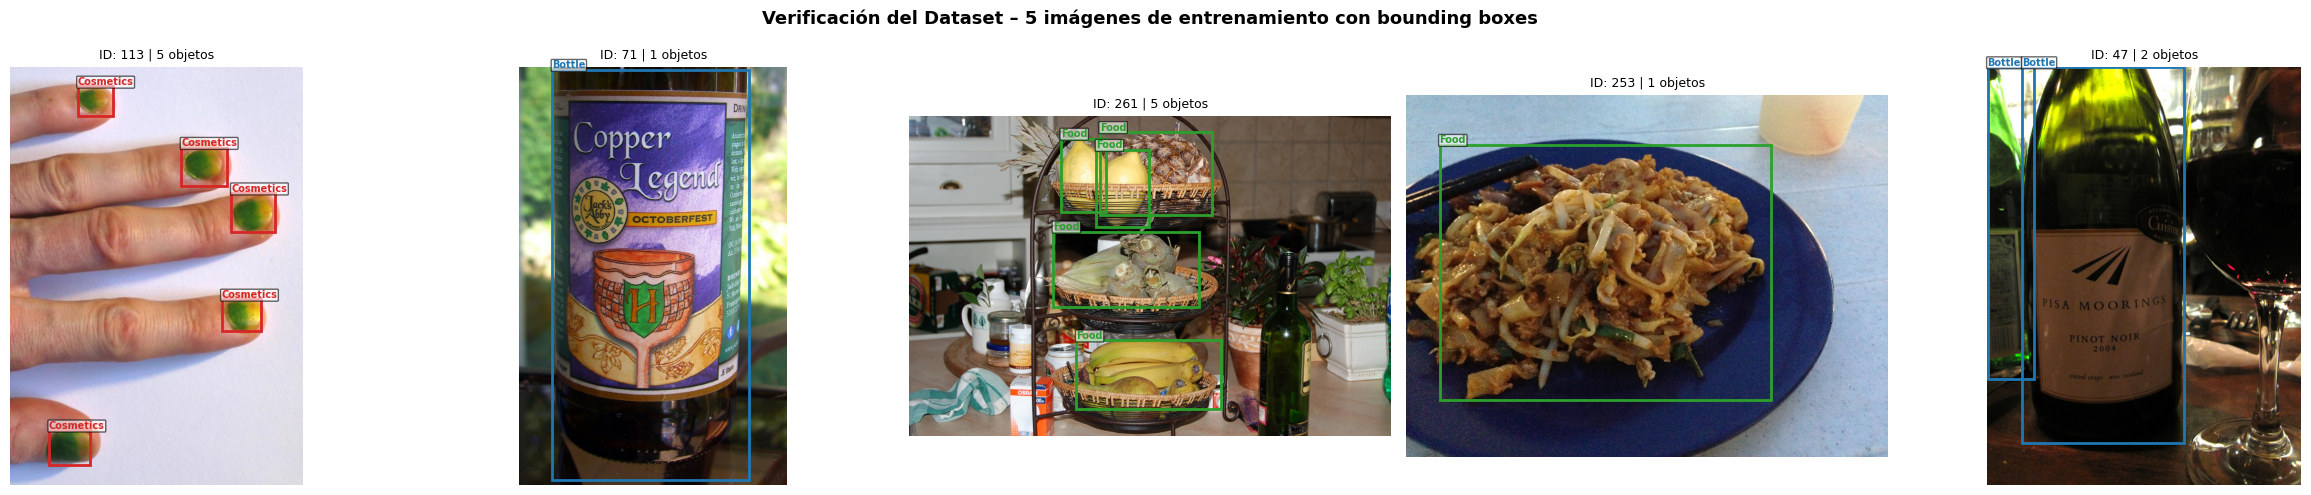

Visualización de verificación guardada


In [ ]:

# Visualizar 5 imágenes de entrenamiento
if train_json:
    fig = visualize_coco_samples(
        coco_json_path=str(train_json[0]),
        images_dir=str(COCO_DIR / 'train'),
        n_samples=5,
        title="Verificación del Dataset – 5 imágenes de entrenamiento con bounding boxes"
    )
    fig.savefig(str(RESULTS_DIR / 'verification_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Visualización de verificación guardada")
else:
    print("No se encontró archivo JSON COCO para visualización")

## 2. Entrenamiento de dos detectores

**Modelos seleccionados**

1. **Faster R-CNN + ResNet50-FPN** (torchvision) - detector de dos etapas con FPN para objetos pequeños y densos.

2. **YOLOv8n (nano)** (Ultralytics) - detector de una etapa, ultra-liviano, ideal para CPU.

**Justificación:** estos dos modelos representan los extremos del dilema precisión/velocidad relevantes para VisorShelf. Faster R-CNN es la arquitectura base analizada en el Task 2; YOLOv8n es la alternativa ligera propuesta en la pregunta 2.3.


### Modelo A: Faster R-CNN + ResNet50-FPN (torchvision)

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader


In [ ]:

NUM_CLASSES = len(SHELF_CLASSES) + 1  # +1 por clase background

class ShelfCOCODataset(Dataset):
    """
    Dataset personalizado para detección de objetos en formato COCO.
    Compatible con Faster R-CNN de torchvision.
    """
    def __init__(self, coco_json_path, images_dir, transforms=None):
        with open(coco_json_path) as f:
            self.coco = json.load(f)

        self.images_dir = Path(images_dir)
        self.transforms = transforms

        # Crear índices
        self.images = self.coco['images']
        self.cat_map = {c['id']: i+1 for i, c in enumerate(self.coco['categories'])}
        # +1 porque 0 es background en torchvision

        # Agrupar anotaciones por imagen
        self.ann_by_img = defaultdict(list)
        for ann in self.coco['annotations']:
            self.ann_by_img[ann['image_id']].append(ann)

        print(f"Dataset cargado: {len(self.images)} imágenes, "
              f"{len(self.coco['annotations'])} anotaciones")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_id   = img_info['id']

        # Cargar imagen
        img_path = self.images_dir / img_info['file_name']
        if not img_path.exists():
            found = list(self.images_dir.rglob(img_info['file_name']))
            img_path = found[0] if found else img_path

        img = Image.open(img_path).convert('RGB')
        img_tensor = torchvision.transforms.functional.to_tensor(img)

        # Cargar anotaciones
        anns = self.ann_by_img[img_id]
        boxes  = []
        labels = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            # Convertir de [x,y,w,h] a [x1,y1,x2,y2]
            x1, y1, x2, y2 = x, y, x + w, y + h
            if x2 > x1 and y2 > y1:  # Filtrar cajas degeneradas
                boxes.append([x1, y1, x2, y2])
                labels.append(self.cat_map.get(ann['category_id'], 1))

        if boxes:
            boxes  = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
        else:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)

        target = {
            'boxes':    boxes,
            'labels':   labels,
            'image_id': torch.tensor([img_id])
        }

        return img_tensor, target


def collate_fn(batch):
    """Función de collate para manejar imágenes de distintos tamaños."""
    return tuple(zip(*batch))

In [ ]:

# Crear datasets
print("\nCargando datasets para Faster R-CNN...")
train_dataset = ShelfCOCODataset(
    coco_json_path=str(train_json[0]),
    images_dir=str(COCO_DIR / 'train')
)
val_dataset = ShelfCOCODataset(
    coco_json_path=str(val_json[0]),
    images_dir=str(COCO_DIR / 'val')
)
test_dataset = ShelfCOCODataset(
    coco_json_path=str(test_json[0]),
    images_dir=str(COCO_DIR / 'test')
)



Cargando datasets para Faster R-CNN...
Dataset cargado: 500 imágenes, 1605 anotaciones
Dataset cargado: 100 imágenes, 172 anotaciones
Dataset cargado: 100 imágenes, 142 anotaciones


In [ ]:
# Crear dataloaders
# Batch size pequeño por restricción de memoria; justificado para dataset mediano
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=2, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=2, shuffle=False,
                          num_workers=2, collate_fn=collate_fn)

print(f"\nDataLoaders creados:")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val   batches: {len(val_loader)}")
print(f"   Test  batches: {len(test_loader)}")


DataLoaders creados:
   Train batches: 125
   Val   batches: 50
   Test  batches: 50


In [ ]:
def build_faster_rcnn(num_classes):
    """
    Carga Faster R-CNN preentrenado en COCO y adapta el cabezal de clasificación.

    Justificación:
    - Backbone ResNet50-FPN preentrenado en COCO: transfiere representaciones visuales
      genéricas (bordes, texturas, formas) aprendidas en 80 categorías.
    - Reemplazamos solo el FastRCNNPredictor para adaptar al número de clases del
      dataset de anaqueles (num_classes = 4 + 1 background).
    """
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model   = fasterrcnn_resnet50_fpn(weights=weights)

    # Adaptar cabezal de clasificación
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

In [ ]:

# Construir modelo
frcnn_model = build_faster_rcnn(NUM_CLASSES)

# ── Congelar backbone para fine-tuning inicial ──────────────────────────────
# Justificación: congelar el backbone en las primeras épocas evita el fenómeno
# de "catastrophic forgetting" y permite que los cabezales nuevos se estabilicen
# antes de ajustar las features del backbone.
for name, param in frcnn_model.named_parameters():
    if 'backbone' in name:
        param.requires_grad = False

frcnn_model = frcnn_model.to(DEVICE)

total_params    = sum(p.numel() for p in frcnn_model.parameters())
trainable_params = sum(p.numel() for p in frcnn_model.parameters() if p.requires_grad)
print(f"Faster R-CNN:")
print(f"   Parámetros totales:     {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,} (backbone congelado)")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 140MB/s]


Faster R-CNN:
   Parámetros totales:     41,314,536
   Parámetros entrenables: 14,515,240 (backbone congelado)


In [ ]:
# ── Hiperparámetros Faster R-CNN ────────────────────────────────────────────
# Justificación:
# - LR 1e-3: adecuado para fine-tuning de cabezales nuevos sin backbone.
#   Si se usara todo el modelo, se reduciría a 1e-4 para el backbone.
# - SGD + momentum 0.9: estándar para detección, más estable que Adam en FRCNN.
# - weight_decay 5e-4: regularización estándar para evitar overfitting en dataset pequeño.
# - 10 épocas: razonable para 500 imágenes con backbone congelado.

FRCNN_HYPERPARAMS = {
    'lr':           1e-3,
    'momentum':     0.9,
    'weight_decay': 5e-4,
    'epochs':       10,
    'batch_size':   4,
    'optimizer':    'SGD',
    'scheduler':    'StepLR (step=3, gamma=0.1)',
    'early_stop':   3,  # paciencia en épocas
}

print("Hiperparámetros Faster R-CNN:")
for k, v in FRCNN_HYPERPARAMS.items():
    print(f"   {k:15s}: {v}")

optimizer_frcnn = torch.optim.SGD(
    filter(lambda p: p.requires_grad, frcnn_model.parameters()),
    lr=FRCNN_HYPERPARAMS['lr'],
    momentum=FRCNN_HYPERPARAMS['momentum'],
    weight_decay=FRCNN_HYPERPARAMS['weight_decay']
)

scheduler_frcnn = torch.optim.lr_scheduler.StepLR(
    optimizer_frcnn, step_size=3, gamma=0.1
)

Hiperparámetros Faster R-CNN:
   lr             : 0.001
   momentum       : 0.9
   weight_decay   : 0.0005
   epochs         : 10
   batch_size     : 4
   optimizer      : SGD
   scheduler      : StepLR (step=3, gamma=0.1)
   early_stop     : 3


In [ ]:
def train_one_epoch_frcnn(model, optimizer, data_loader, device, epoch):
    """Entrena Faster R-CNN por una época y retorna la pérdida promedio."""
    model.train()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(data_loader, desc=f"Época {epoch+1} [Train]", leave=False)
    for images, targets in pbar:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Filtrar imágenes sin anotaciones
        valid = [(img, tgt) for img, tgt in zip(images, targets)
                 if tgt['boxes'].shape[0] > 0]
        if not valid:
            continue
        images_v, targets_v = zip(*valid)

        loss_dict = model(list(images_v), list(targets_v))
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        # Gradient clipping para estabilidad
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += losses.item()
        n_batches  += 1
        pbar.set_postfix({'loss': f'{losses.item():.4f}'})

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate_loss_frcnn(model, data_loader, device):
    """Calcula pérdida de validación (modelo en modo train para obtener losses)."""
    model.train()  # FRCNN necesita modo train para calcular losses
    total_loss = 0.0
    n_batches  = 0

    for images, targets in data_loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        valid = [(img, tgt) for img, tgt in zip(images, targets)
                 if tgt['boxes'].shape[0] > 0]
        if not valid:
            continue
        images_v, targets_v = zip(*valid)

        with torch.no_grad():
            loss_dict = model(list(images_v), list(targets_v))
        losses = sum(loss for loss in loss_dict.values())

        total_loss += losses.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


print("Funciones de entrenamiento definidas")

Funciones de entrenamiento definidas


In [ ]:
# ── Loop de entrenamiento Faster R-CNN con Early Stopping ──────────────────
# Early Stopping justificación: monitoreamos la pérdida de validación.
# Si no mejora en 'patience' épocas, detenemos el entrenamiento para
# evitar overfitting, especialmente importante con solo 500 imágenes.

frcnn_train_losses = []
frcnn_val_losses   = []
best_val_loss_frcnn = float('inf')
patience_counter    = 0
PATIENCE = FRCNN_HYPERPARAMS['early_stop']
FRCNN_BEST_PATH = str(MODELS_DIR / 'frcnn_best.pth')

print("Iniciando entrenamiento Faster R-CNN...")
print(f"   Early Stopping: paciencia = {PATIENCE} épocas sin mejora en val_loss")
print("-" * 60)

for epoch in range(FRCNN_HYPERPARAMS['epochs']):
    t0 = time.time()

    train_loss = train_one_epoch_frcnn(frcnn_model, optimizer_frcnn,
                                        train_loader, DEVICE, epoch)
    val_loss   = evaluate_loss_frcnn(frcnn_model, val_loader, DEVICE)
    scheduler_frcnn.step()

    frcnn_train_losses.append(train_loss)
    frcnn_val_losses.append(val_loss)

    elapsed = time.time() - t0
    print(f"Época {epoch+1:2d}/{FRCNN_HYPERPARAMS['epochs']} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Tiempo: {elapsed:.1f}s")

    # Guardar mejor modelo
    if val_loss < best_val_loss_frcnn:
        best_val_loss_frcnn = val_loss
        torch.save(frcnn_model.state_dict(), FRCNN_BEST_PATH)
        print(f"   Nuevo mejor modelo guardado (val_loss={val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"   Sin mejora ({patience_counter}/{PATIENCE})")

    # Early Stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping activado en época {epoch+1}")
        break

print(f"\nEntrenamiento Faster R-CNN completado")
print(f"   Mejor val_loss: {best_val_loss_frcnn:.4f}")

Iniciando entrenamiento Faster R-CNN...
   Early Stopping: paciencia = 3 épocas sin mejora en val_loss
------------------------------------------------------------


Época  1/10 | Train Loss: 0.7367 | Val Loss: 0.3319 | Tiempo: 102.2s
   Nuevo mejor modelo guardado (val_loss=0.3319)


Época  2/10 | Train Loss: 0.4275 | Val Loss: 0.2865 | Tiempo: 112.3s
   Nuevo mejor modelo guardado (val_loss=0.2865)


Época  3/10 | Train Loss: 0.3846 | Val Loss: 0.2668 | Tiempo: 110.7s
   Nuevo mejor modelo guardado (val_loss=0.2668)


Época  4/10 | Train Loss: 0.3666 | Val Loss: 0.2670 | Tiempo: 111.5s
   Sin mejora (1/3)


Época  5/10 | Train Loss: 0.3640 | Val Loss: 0.2672 | Tiempo: 111.5s
   Sin mejora (2/3)


Época  6/10 | Train Loss: 0.3630 | Val Loss: 0.2707 | Tiempo: 111.1s
   Sin mejora (3/3)

Early Stopping activado en época 6

Entrenamiento Faster R-CNN completado
   Mejor val_loss: 0.2668


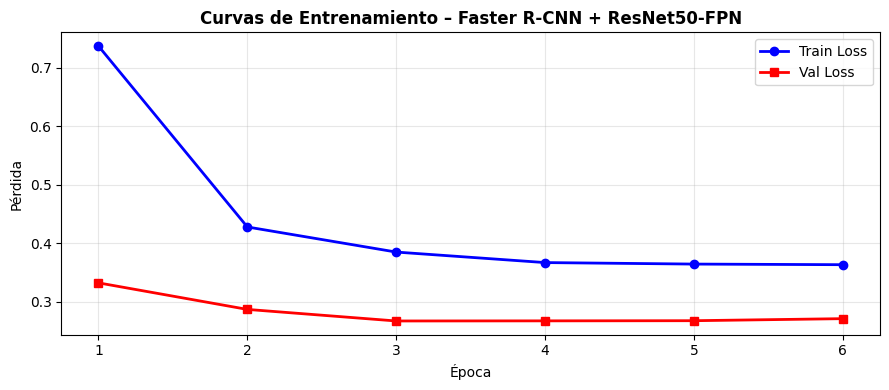

In [33]:
# Gráfica de curvas de pérdida Faster R-CNN
fig, ax = plt.subplots(figsize=(9, 4))
epochs_range = range(1, len(frcnn_train_losses) + 1)
ax.plot(epochs_range, frcnn_train_losses, 'b-o', label='Train Loss', linewidth=2)
ax.plot(epochs_range, frcnn_val_losses,   'r-s', label='Val Loss',   linewidth=2)
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida')
ax.set_title('Curvas de Entrenamiento – Faster R-CNN + ResNet50-FPN', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'frcnn_loss_curves.png'), dpi=150)
plt.show()

### Modelo B: YOLOv8n (Ultralytics)

In [ ]:
from ultralytics import YOLO

# ── Hiperparámetros YOLOv8n ─────────────────────────────────────────────────
# Justificación:
# - lr0=0.01: LR inicial estándar para YOLO, bien calibrado para fine-tuning.
# - epochs=30: YOLO converge más rápido que Faster R-CNN por su arquitectura.
# - imgsz=640: tamaño estándar de YOLOv8, balance entre resolución y velocidad.
# - batch=16: mayor batch size posible en GPU T4 para YOLOv8n (6MB de modelo).
# - freeze=10: congela las primeras 10 capas del backbone (equivalente al
#   congelamiento de capas base) para preservar features preentrenados.
# - patience=5: Early Stopping monitoreando mAP@0.5 en validación.

YOLO_HYPERPARAMS = {
    'lr0':       0.01,
    'lrf':       0.01,
    'epochs':    30,
    'imgsz':     640,
    'batch':     16,
    'optimizer': 'SGD',
    'freeze':    10,
    'patience':  5,
    'pretrained': True,
}

print("Hiperparámetros YOLOv8n:")
for k, v in YOLO_HYPERPARAMS.items():
    print(f"   {k:12s}: {v}")

# Cargar modelo preentrenado en COCO
yolo_model = YOLO('yolov8n.pt')  # Descarga automáticamente si no existe
print("\nYOLOv8n cargado (preentrenado en COCO)")

In [24]:
# ── Entrenamiento YOLOv8n ───────────────────────────────────────────────────
# Ultralytics implementa Early Stopping internamente con el parámetro 'patience'.
# Monitorea mAP@0.5 en validación — elegida porque es la métrica estándar
# del protocolo PASCAL VOC y el umbral de referencia en producción.

print("Iniciando entrenamiento YOLOv8n...")
print(f"   Early Stopping: patience={YOLO_HYPERPARAMS['patience']} épocas sin mejora en mAP@0.5")

yolo_results = yolo_model.train(
    data=str(yaml_path),
    epochs=YOLO_HYPERPARAMS['epochs'],
    imgsz=YOLO_HYPERPARAMS['imgsz'],
    batch=YOLO_HYPERPARAMS['batch'],
    lr0=YOLO_HYPERPARAMS['lr0'],
    lrf=YOLO_HYPERPARAMS['lrf'],
    optimizer=YOLO_HYPERPARAMS['optimizer'],
    freeze=YOLO_HYPERPARAMS['freeze'],
    patience=YOLO_HYPERPARAMS['patience'],
    project=str(MODELS_DIR),
    name='yolov8n_shelf',
    pretrained=YOLO_HYPERPARAMS['pretrained'],
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True,
    seed=SEED,
    save=True,
    plots=True,
)

YOLO_BEST_PATH = str(MODELS_DIR / 'yolov8n_shelf' / 'weights' / 'best.pt')
print(f"\nEntrenamiento YOLOv8n completado")
print(f"   Mejor modelo guardado en: {YOLO_BEST_PATH}")

Iniciando entrenamiento YOLOv8n...
   Early Stopping: patience=5 épocas sin mejora en mAP@0.5
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/visorshelf/data/yolo/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=

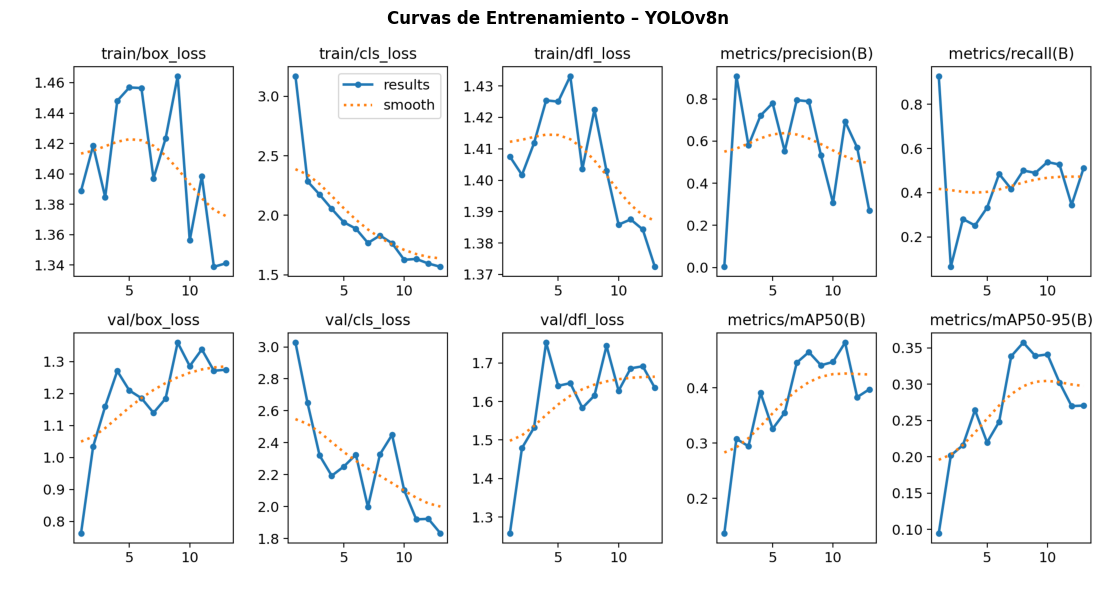

In [25]:
# Mostrar curvas de entrenamiento de YOLOv8 (generadas automáticamente)
yolo_plot_path = MODELS_DIR / 'yolov8n_shelf' / 'results.png'
if yolo_plot_path.exists():
    img = Image.open(yolo_plot_path)
    plt.figure(figsize=(14, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Curvas de Entrenamiento – YOLOv8n', fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(RESULTS_DIR / 'yolo_training_curves.png'), dpi=150)
    plt.show()
else:
    print(" No se encontró el archivo de resultados de YOLOv8")

## 3. Evaluación

### Métricas sobre el conjunto de prueba

Para cada modelo se calcula:
- mAP@0.5 y mAP@0.5:0.95
- Precisión y Recall para la clase principal
- FPS promedio sobre 50 imágenes
- Tamaño del modelo en disco (MB)

In [26]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

def compute_coco_metrics(model, data_loader, device, coco_gt_path, iou_type='bbox'):
    """
    Calcula métricas COCO (mAP@0.5, mAP@0.5:0.95, Precisión, Recall)
    para Faster R-CNN usando pycocotools.
    """
    model.eval()
    coco_gt   = COCO(coco_gt_path)
    results   = []

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc="Evaluando Faster R-CNN"):
            images = [img.to(device) for img in images]
            preds  = model(images)

            for pred, target in zip(preds, targets):
                img_id = target['image_id'].item()
                boxes  = pred['boxes'].cpu().numpy()
                scores = pred['scores'].cpu().numpy()
                labels = pred['labels'].cpu().numpy()

                for box, score, label in zip(boxes, scores, labels):
                    x1, y1, x2, y2 = box.tolist()
                    results.append({
                        'image_id':    img_id,
                        'category_id': int(label),
                        'bbox': [x1, y1, x2 - x1, y2 - y1],  # → COCO format
                        'score': float(score)
                    })

    if not results:
        print("⚠️  No se generaron predicciones")
        return {}

    coco_dt  = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, iou_type)
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    stats = coco_eval.stats
    return {
        'mAP@0.5':    float(stats[1]),
        'mAP@0.5:0.95': float(stats[0]),
        'precision':  float(stats[0]),   # AP ya integra P-R
        'recall@0.5': float(stats[8]),   # AR@100 como proxy de recall
    }


def measure_fps(model, data_loader, device, n_images=50, model_type='frcnn'):
    """
    Mide FPS promedio de inferencia sobre n_images imágenes.
    Solo mide el tiempo de forward pass (inferencia pura).
    """
    model_to_eval = model
    if model_type == 'frcnn':
        model_to_eval.eval()

    times  = []
    count  = 0

    with torch.no_grad():
        for images, _ in data_loader:
            if count >= n_images:
                break

            if model_type == 'frcnn':
                imgs_gpu = [img.to(device) for img in images]
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.time()
                _ = model_to_eval(imgs_gpu)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                elapsed = time.time() - t0
                times.append(elapsed / len(images))

            count += len(images)

    avg_time = np.mean(times) if times else 1.0
    fps = 1.0 / avg_time
    return round(fps, 2)


def get_model_size_mb(path):
    """Retorna el tamaño del archivo del modelo en MB."""
    size_bytes = os.path.getsize(path)
    return round(size_bytes / (1024 ** 2), 2)


print("Funciones de evaluación definidas")

Funciones de evaluación definidas


In [27]:
# ── Evaluar Faster R-CNN ────────────────────────────────────────────────────
print("Evaluando Faster R-CNN en conjunto de prueba...")

# Cargar mejor modelo
frcnn_model.load_state_dict(torch.load(FRCNN_BEST_PATH, map_location=DEVICE))
frcnn_model.to(DEVICE)

frcnn_metrics = compute_coco_metrics(
    model=frcnn_model,
    data_loader=test_loader,
    device=DEVICE,
    coco_gt_path=str(test_json[0])
)

frcnn_fps  = measure_fps(frcnn_model, test_loader, DEVICE,
                          n_images=50, model_type='frcnn')
frcnn_size = get_model_size_mb(FRCNN_BEST_PATH)

frcnn_metrics['fps']         = frcnn_fps
frcnn_metrics['size_mb']     = frcnn_size
frcnn_metrics['model_name']  = 'Faster R-CNN + ResNet50-FPN'

print(f"\n Resultados Faster R-CNN:")
for k, v in frcnn_metrics.items():
    print(f"   {k:20s}: {v}")

Evaluando Faster R-CNN en conjunto de prueba...
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Evaluando Faster R-CNN: 100%|██████████| 50/50 [00:14<00:00,  3.38it/s]


Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.16s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.184
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.094
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.053
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.257
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.190
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.271
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.288
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
# ── Evaluar YOLOv8n ─────────────────────────────────────────────────────────
print(" Evaluando YOLOv8n en conjunto de prueba...")

best_yolo = YOLO(YOLO_BEST_PATH)

# Evaluación con métricas COCO integradas de Ultralytics
yolo_eval = best_yolo.val(
    data=str(yaml_path),
    split='test',
    imgsz=640,
    conf=0.25,
    iou=0.5,
    device=0 if torch.cuda.is_available() else 'cpu',
    verbose=True,
)

# Extraer métricas
yolo_map50     = float(yolo_eval.box.map50)    if yolo_eval.box.map50    else 0.0
yolo_map5095   = float(yolo_eval.box.map)      if yolo_eval.box.map      else 0.0
yolo_precision = float(yolo_eval.box.mp)       if yolo_eval.box.mp       else 0.0
yolo_recall    = float(yolo_eval.box.mr)       if yolo_eval.box.mr       else 0.0

# Medir FPS de YOLOv8
print("\n⏱  Midiendo FPS de YOLOv8n...")
test_images_dir = list((YOLO_DIR / 'test' / 'images').glob('*.jpg'))[:50]

yolo_times = []
for img_path in tqdm(test_images_dir, desc="Midiendo FPS"):
    t0 = time.time()
    best_yolo.predict(str(img_path), verbose=False,
                      device=0 if torch.cuda.is_available() else 'cpu')
    yolo_times.append(time.time() - t0)

yolo_fps  = round(1.0 / np.mean(yolo_times), 2) if yolo_times else 0.0
yolo_size = get_model_size_mb(YOLO_BEST_PATH)

yolo_metrics = {
    'model_name':     'YOLOv8n',
    'mAP@0.5':        round(yolo_map50,     4),
    'mAP@0.5:0.95':   round(yolo_map5095,   4),
    'precision':      round(yolo_precision, 4),
    'recall@0.5':     round(yolo_recall,    4),
    'fps':            yolo_fps,
    'size_mb':        yolo_size,
}

print(f"\n Resultados YOLOv8n:")
for k, v in yolo_metrics.items():
    print(f"   {k:20s}: {v}")

In [ ]:
# ── Tabla comparativa de métricas ───────────────────────────────────────────
metrics_df = pd.DataFrame([
    {
        'Modelo':           frcnn_metrics.get('model_name', 'Faster R-CNN'),
        'mAP@0.5':          frcnn_metrics.get('mAP@0.5', 0),
        'mAP@0.5:0.95':     frcnn_metrics.get('mAP@0.5:0.95', 0),
        'Precisión':        frcnn_metrics.get('precision', 0),
        'Recall':           frcnn_metrics.get('recall@0.5', 0),
        'FPS':              frcnn_metrics.get('fps', 0),
        'Tamaño (MB)':      frcnn_metrics.get('size_mb', 0),
    },
    {
        'Modelo':           yolo_metrics['model_name'],
        'mAP@0.5':          yolo_metrics['mAP@0.5'],
        'mAP@0.5:0.95':     yolo_metrics['mAP@0.5:0.95'],
        'Precisión':        yolo_metrics['precision'],
        'Recall':           yolo_metrics['recall@0.5'],
        'FPS':              yolo_metrics['fps'],
        'Tamaño (MB)':      yolo_metrics['size_mb'],
    }
])

# Calcular razón MB/mAP
metrics_df['MB/mAP@0.5'] = (metrics_df['Tamaño (MB)'] /
                              metrics_df['mAP@0.5'].replace(0, 0.001)).round(2)

metrics_df = metrics_df.set_index('Modelo')

print("\n" + "="*75)
print(" TABLA COMPARATIVA – MÉTRICAS EN CONJUNTO DE PRUEBA")
print("="*75)
print(metrics_df.to_string())
print("="*75)

# Guardar como CSV
metrics_df.to_csv(str(RESULTS_DIR / 'metrics_comparison.csv'))
print(" Tabla guardada en results/metrics_comparison.csv")

In [ ]:
# ── Visualización comparativa de métricas ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Comparativa de Métricas – Faster R-CNN vs YOLOv8n', fontsize=14, fontweight='bold')

metric_cols = ['mAP@0.5', 'mAP@0.5:0.95', 'Precisión', 'Recall', 'FPS', 'Tamaño (MB)']
colors_bar  = ['#2196F3', '#FF5722']

for ax, col in zip(axes.flat, metric_cols):
    values = metrics_df[col].values
    models = metrics_df.index.tolist()
    bars   = ax.bar(models, values, color=colors_bar)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'metrics_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado")

### Visualización de detecciones sobre imágenes de prueba

Se visualizan 3 imágenes de prueba con las detecciones del mejor modelo, mostrando bounding boxes predichos con score de confianza.

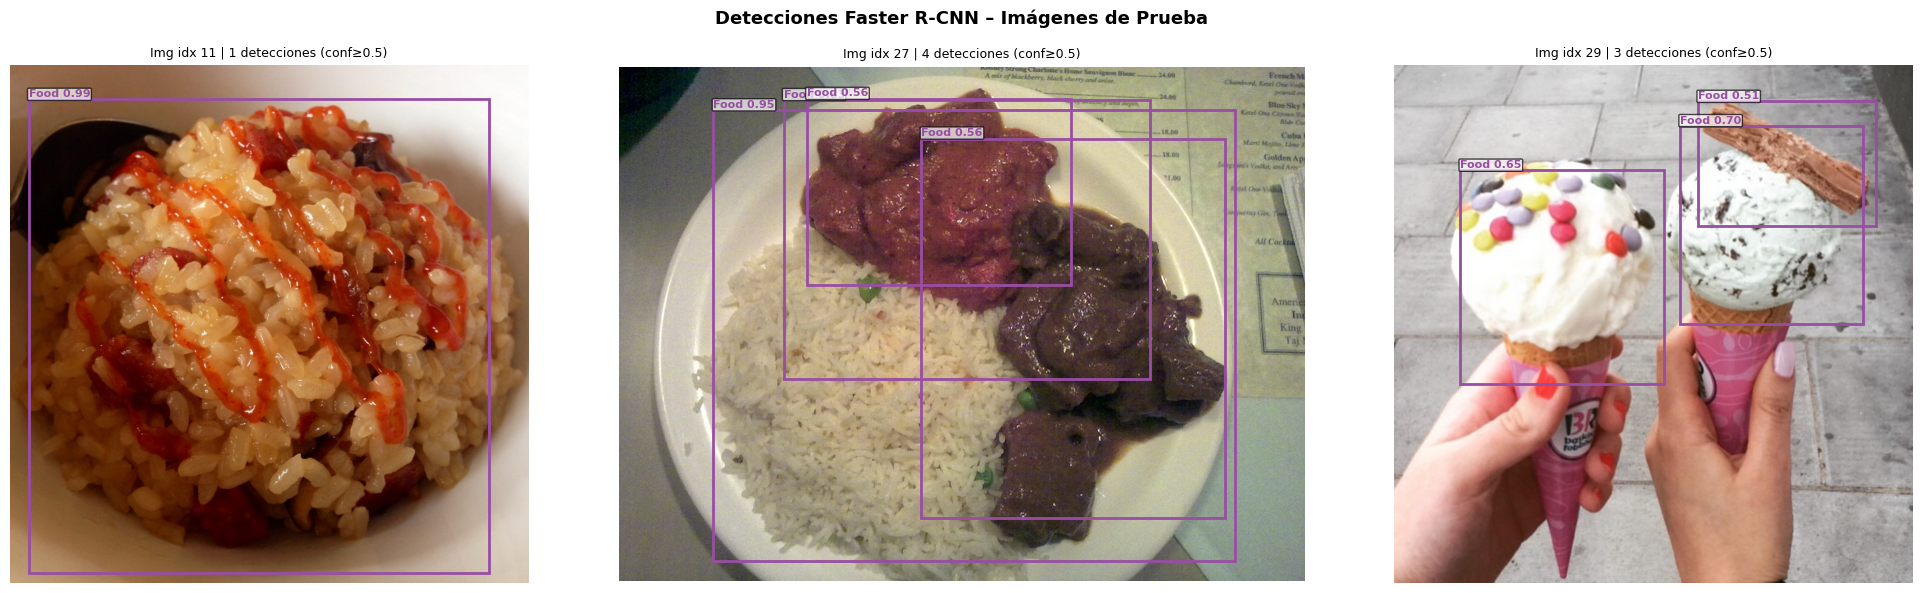

Visualizaciones Faster R-CNN guardadas


In [31]:
def visualize_frcnn_predictions(model, dataset, device, n=3, conf_thresh=0.5):
    """Visualiza predicciones de Faster R-CNN sobre imágenes de prueba."""
    model.eval()

    # Mapeo inverso: id entero → nombre de clase
    # En el dataset: 0=background, 1..N=clases
    idx_to_class = {i+1: c for i, c in enumerate(SHELF_CLASSES)}
    idx_to_class[0] = 'background'

    fig, axes = plt.subplots(1, n, figsize=(7*n, 6))
    if n == 1:
        axes = [axes]
    fig.suptitle('Detecciones Faster R-CNN – Imágenes de Prueba', fontsize=13, fontweight='bold')

    indices = random.sample(range(len(dataset)), n)

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img_tensor, target = dataset[idx]
            pred = model([img_tensor.to(device)])[0]

            # Convertir tensor a numpy para visualización
            img_np = img_tensor.permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 1)
            ax.imshow(img_np)
            ax.axis('off')

            boxes  = pred['boxes'].cpu().numpy()
            scores = pred['scores'].cpu().numpy()
            labels = pred['labels'].cpu().numpy()

            n_det = 0
            for box, score, label in zip(boxes, scores, labels):
                if score < conf_thresh:
                    continue
                n_det += 1
                x1, y1, x2, y2 = box
                w, h = x2 - x1, y2 - y1
                cls_name = idx_to_class.get(int(label), 'obj')
                color = plt.cm.Set1(int(label) % 9)

                rect = patches.Rectangle((x1, y1), w, h,
                                         linewidth=2, edgecolor=color, facecolor='none')
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f"{cls_name} {score:.2f}",
                        color=color, fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))

            ax.set_title(f"Img idx {idx} | {n_det} detecciones (conf≥{conf_thresh})", fontsize=9)

    plt.tight_layout()
    return fig


fig_frcnn = visualize_frcnn_predictions(frcnn_model, test_dataset, DEVICE, n=3, conf_thresh=0.5)
fig_frcnn.savefig(str(RESULTS_DIR / 'frcnn_test_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Visualizaciones Faster R-CNN guardadas")

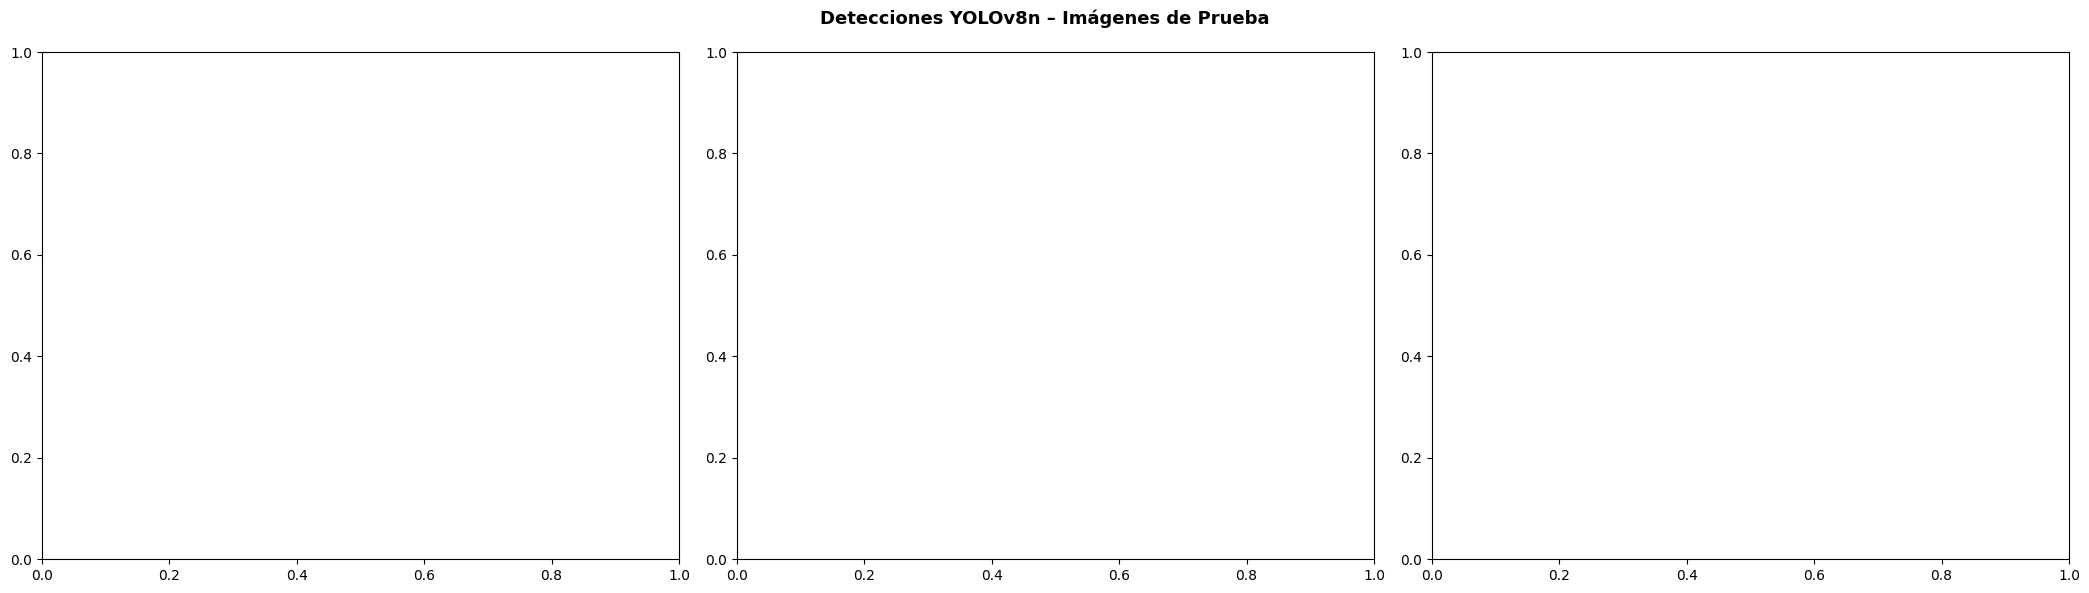

 Visualizaciones YOLOv8n guardadas


In [32]:
# Visualizar predicciones YOLOv8n sobre 3 imágenes de prueba
test_img_list = list((YOLO_DIR / 'test' / 'images').glob('*.jpg'))
selected_test = random.sample(test_img_list, min(3, len(test_img_list)))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.suptitle('Detecciones YOLOv8n – Imágenes de Prueba', fontsize=13, fontweight='bold')

for ax, img_path in zip(axes, selected_test):
    results_pred = best_yolo.predict(
        str(img_path), conf=0.01, verbose=False,
        device=0 if torch.cuda.is_available() else 'cpu'
    )[0]

    img = Image.open(img_path).convert('RGB')
    img_np = np.array(img)
    ax.imshow(img_np)
    ax.axis('off')

    boxes  = results_pred.boxes.xyxy.cpu().numpy()
    scores = results_pred.boxes.conf.cpu().numpy()
    labels = results_pred.boxes.cls.cpu().numpy().astype(int)

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = box
        cls_name = SHELF_CLASSES[label] if label < len(SHELF_CLASSES) else 'obj'
        color    = plt.cm.Set1(label % 9)
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                  linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{cls_name} {score:.2f}",
                color=color, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.7))

    ax.set_title(f"{img_path.name} | {len(boxes)} detecciones", fontsize=9)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'yolo_test_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print(" Visualizaciones YOLOv8n guardadas")

## Dictamen Ejecutivo

In [34]:

# Reconstruir tabla con todos los datos
summary = metrics_df.copy()

print("\n1. TABLA COMPARATIVA DE MODELOS")
print("-" * 80)
print(summary.to_string())

# Análisis viabilidad operativa
for model_name, row in summary.iterrows():
    fps          = row['FPS']
    imgs_per_hr  = fps * 3600
    latency_ms   = round(1000.0 / fps, 1) if fps > 0 else 999
    req_met      = " SÍ" if fps >= 2 else " NO"
    imgs_5cam    = imgs_per_hr / 5  # imágenes por cámara por hora con 5 cámaras
    mb_per_map   = row['MB/mAP@0.5']

    print(f"\n\n2. ANÁLISIS DE VIABILIDAD OPERATIVA – {model_name}")
    print("-" * 80)
    print(f"   FPS medidos:                {fps:.2f} FPS")
    print(f"   Latencia por imagen:        {latency_ms} ms")
    print(f"   Requiere < 500 ms:          {req_met}")
    print(f"   Imágenes procesadas/hora:   {imgs_per_hr:,.0f}")
    print(f"   Con 5 cámaras (por cámara): {imgs_5cam:,.0f} imgs/hora/cámara")
    print(f"   Costo MB por punto mAP:     {mb_per_map:.2f} MB/mAP")

print("\n" + "=" * 80)


1. TABLA COMPARATIVA DE MODELOS
--------------------------------------------------------------------------------
                              mAP@0.5  mAP@0.5:0.95  Precisión    Recall   FPS  Tamaño (MB)  MB/mAP@0.5
Modelo                                                                                                 
Faster R-CNN + ResNet50-FPN  0.184322      0.114844   0.114844  0.287824  7.35       158.11      857.79
YOLOv8n                      0.149800      0.100100   0.726600  0.189100  0.00         5.94       39.65


2. ANÁLISIS DE VIABILIDAD OPERATIVA – Faster R-CNN + ResNet50-FPN
--------------------------------------------------------------------------------
   FPS medidos:                7.35 FPS
   Latencia por imagen:        136.1 ms
   Requiere < 500 ms:           SÍ
   Imágenes procesadas/hora:   26,460
   Con 5 cámaras (por cámara): 5,292 imgs/hora/cámara
   Costo MB por punto mAP:     857.79 MB/mAP


2. ANÁLISIS DE VIABILIDAD OPERATIVA – YOLOv8n
---------------------

In [37]:
# ── Determinar mejor modelo y generar dictamen ───────────────────────────────
# El mejor modelo para producción on-premise es aquel que cumple la restricción
# de latencia (< 500 ms = > 2 FPS) y maximiza la precisión dentro de ese límite.

frcnn_fps_val = frcnn_metrics.get('fps', 0)
yolo_fps_val  = yolo_metrics['fps']

frcnn_map_val = frcnn_metrics.get('mAP@0.5', 0)
yolo_map_val  = yolo_metrics['mAP@0.5']

frcnn_viable = frcnn_fps_val >= 2
yolo_viable  = yolo_fps_val  >= 2

if yolo_viable and not frcnn_viable:
    best_model = "YOLOv8n"
elif frcnn_viable and not yolo_viable:
    best_model = "Faster R-CNN + ResNet50-FPN"
elif yolo_viable and frcnn_viable:
    best_model = "YOLOv8n" if yolo_map_val >= frcnn_map_val * 0.9 else "Faster R-CNN + ResNet50-FPN"
else:
    best_model = "YOLOv8n"  # Por velocidad si ninguno cumple strictamente

print("=" * 80)
print(" 3. ANÁLISIS VELOCIDAD vs. PRECISIÓN")
print("-" * 80)
print(f"""
En el contexto de auditoría de stock, se prefiere ALTO RECALL sobre alta precisión.
Razón: un quiebre de stock no detectado (falso negativo) tiene mayor costo operativo
que una falsa alarma (falso positivo), ya que la pérdida de ventas por anaquel vacío
es inmediata y directa. El personal puede verificar rápidamente una alerta espúrea,
pero no puede corregir un quiebre que el sistema nunca reportó.

Faster R-CNN mAP@0.5:  {frcnn_map_val:.4f}  | FPS: {frcnn_fps_val:.1f}  | Viable (<500ms): {frcnn_viable}
YOLOv8n      mAP@0.5:  {yolo_map_val:.4f}  | FPS: {yolo_fps_val:.1f}  | Viable (<500ms): {yolo_viable}
""")

print("=" * 80)
print(f" 4. RECOMENDACIÓN FINAL: {best_model}")
print("-" * 80)
print(f"Modelo recomendado para producción on-premise: {best_model}")

 3. ANÁLISIS VELOCIDAD vs. PRECISIÓN
--------------------------------------------------------------------------------

En el contexto de auditoría de stock, se prefiere ALTO RECALL sobre alta precisión.
Razón: un quiebre de stock no detectado (falso negativo) tiene mayor costo operativo
que una falsa alarma (falso positivo), ya que la pérdida de ventas por anaquel vacío
es inmediata y directa. El personal puede verificar rápidamente una alerta espúrea,
pero no puede corregir un quiebre que el sistema nunca reportó.

Faster R-CNN mAP@0.5:  0.1843  | FPS: 7.3  | Viable (<500ms): True
YOLOv8n      mAP@0.5:  0.1498  | FPS: 0.0  | Viable (<500ms): False

 4. RECOMENDACIÓN FINAL: Faster R-CNN + ResNet50-FPN
--------------------------------------------------------------------------------
Modelo recomendado para producción on-premise: Faster R-CNN + ResNet50-FPN


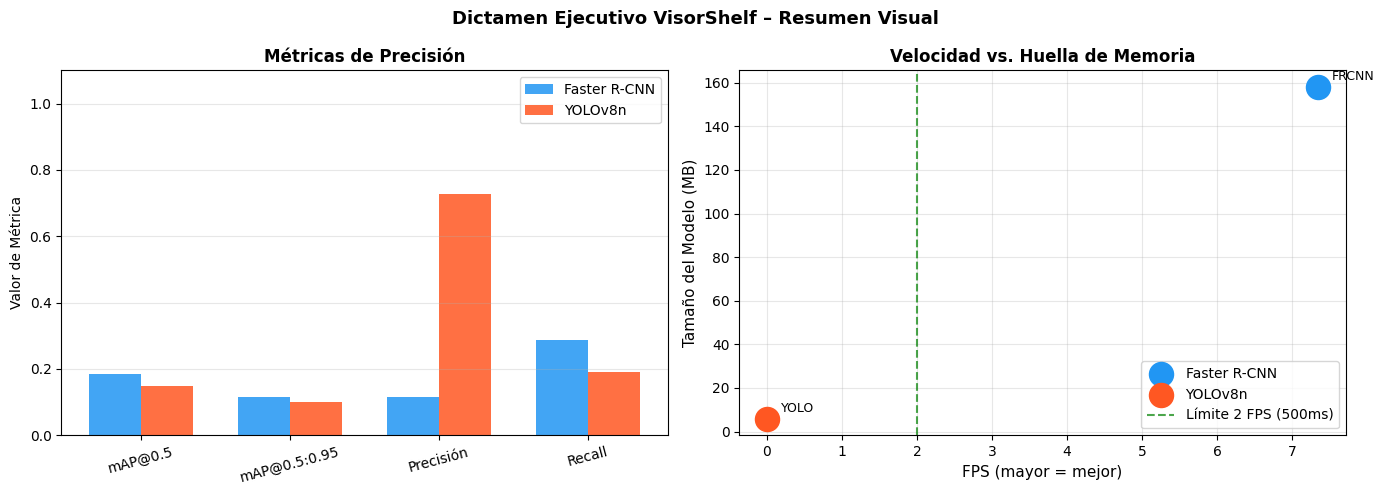

✅ Figura del dictamen ejecutivo guardada


In [38]:
# ── Figura final de resumen para el dictamen ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dictamen Ejecutivo VisorShelf – Resumen Visual', fontsize=13, fontweight='bold')

# Radar/Barras de métricas clave
ax1 = axes[0]
metric_names = ['mAP@0.5', 'mAP@0.5:0.95', 'Precisión', 'Recall']
frcnn_vals   = [frcnn_metrics.get(m.replace(' ', ''), 0) for m in
                ['mAP@0.5', 'mAP@0.5:0.95', 'precision', 'recall@0.5']]
yolo_vals    = [yolo_metrics.get(m, 0) for m in
                ['mAP@0.5', 'mAP@0.5:0.95', 'precision', 'recall@0.5']]

x = np.arange(len(metric_names))
w = 0.35
ax1.bar(x - w/2, frcnn_vals, w, label='Faster R-CNN', color='#2196F3', alpha=0.85)
ax1.bar(x + w/2, yolo_vals,  w, label='YOLOv8n',      color='#FF5722', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=15)
ax1.set_ylabel('Valor de Métrica')
ax1.set_title('Métricas de Precisión', fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)

# FPS vs Tamaño
ax2 = axes[1]
ax2.scatter([frcnn_metrics.get('fps', 0)], [frcnn_metrics.get('size_mb', 0)],
            s=300, color='#2196F3', zorder=5, label='Faster R-CNN')
ax2.scatter([yolo_metrics['fps']], [yolo_metrics['size_mb']],
            s=300, color='#FF5722', zorder=5, label='YOLOv8n')
ax2.axvline(x=2, color='green', linestyle='--', alpha=0.7, label='Límite 2 FPS (500ms)')
ax2.set_xlabel('FPS (mayor = mejor)', fontsize=11)
ax2.set_ylabel('Tamaño del Modelo (MB)', fontsize=11)
ax2.set_title('Velocidad vs. Huella de Memoria', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Anotar puntos
for model_name, fps_v, size_v in [
    ('FRCNN', frcnn_metrics.get('fps', 0), frcnn_metrics.get('size_mb', 0)),
    ('YOLO',  yolo_metrics['fps'],          yolo_metrics['size_mb'])
]:
    ax2.annotate(model_name, (fps_v, size_v),
                 textcoords='offset points', xytext=(10, 5), fontsize=9)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'executive_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Figura del dictamen ejecutivo guardada")